In [1]:
# Импорты сюдаа
import numpy as np
import matplotlib.pyplot as plt
import segyio
import segyio.tools
from scipy.signal import correlate
from scipy.stats import spearmanr, pearsonr
from scipy.signal import find_peaks, hilbert
from scipy.optimize import minimize_scalar, minimize
from scipy.optimize import minimize, differential_evolution
from typing import List, Dict, Tuple, Callable
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from itertools import product
from scipy.signal import correlate
from tqdm import tqdm

In [2]:
class RickerWaveletGenerator:
    """
    Генератор синтетических сейсмических трасс на основе свёрточной модели.
    """
    
    def __init__(self, wavelet_type='ricker', wavelet_freq=30, dt=0.002, length=0.128):
        """
        Инициализация генератора.

        Параметры:
        ----------
        wavelet_type : str
                тип вейвлета по умолчанию ('ricker', других пока нет)
        wavelet_freq : float
                доминантная частота вейвлета в Гц (чем выше частота, тем уже импульс)
        dt : float
                интервал дискретизации в секундах (шаг по времени)
        length : float
                полная длина вейвлета в секундах по умолчанию (от -length/2 до length/2)
        """
        self.wavelet_type = wavelet_type
        self.wavelet_freq = wavelet_freq
        self.length = length
        self.dt = dt
        
        self.wavelet_time, self.wavelet = self._create_ricker_wavelet()
    
    def _create_ricker_wavelet(self):
        """
        Создание вейвлета Рикера.

        Формула: (1 - 2π²f²t²) * exp(-π²f²t²)
        где f - доминантная частота, t - время
    
        Возвращает:
        ----------
        wavelet_time : np.ndarray
                временная ось вейвлета (от -length/2 до length/2 с шагом dt)
        wavelet : np.ndarray
                амплитуды вейвлета (не нормированные)
        """
        # Временная сетка для импульса
        t = np.arange(-self.length/2, self.length/2, self.dt) #создаёт массив чисел от -self.length/2 (-0.064) до self.length/2 (0.064) с шагом self.dt (0.002 сек)
        f = self.wavelet_freq
        
        # Формула вейвлета Рикера
        tau = np.pi * f * t
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        
        # Нормализация (максимальная амплитуда = 1)
        #wavelet = wavelet / np.max(np.abs(wavelet))
        
        return t, wavelet
    
    def get_wavelet(self):
        """
        Возвращает импульс источника (вейвлет). Создаёт его, если ещё не создан, иначе возвращает существующий.
    
        Возвращает:
        ----------
        tuple : (wavelet_time, wavelet)
                временная ось и амплитуды вейвлета
        """
        if self.wavelet is None:
            if self.wavelet_type == 'ricker':
                t, w = self._create_ricker_wavelet()
                self.wavelet_time = t
                self.wavelet = w
            else:
                raise ValueError(f"Неподдерживаемый тип вейвлета: {self.wavelet_type}")
        return self.wavelet_time, self.wavelet
    
    def generate_trace(self, reflectivity_series, noise_level=0.0):
        """
        Генерирует сейсмическую трассу по коэффициентам отражения.
    
        Параметры:
        ----------
        reflectivity_series : np.ndarray
                временной ряд коэффициентов отражения (импульсная характеристика среды); длина массиво определяет длительность трассы в отсчётах
        noise_level : float
                уровень шума (0 = без шума по умолчанию, 0.05 = 5% от RMS сигнала)
    
        Возвращает:
        ----------
        trace : np.ndarray
                синтетическая сейсмическая трасса (результат свёртки)
    
        Алгоритм:
        ----------
        1. Вейвлет
        2. Выполнение свёртки: trace = reflectivity * wavelet
        3. Обрезка до длины исходного ряда
        4. Добавление шума (если необходимо)
        """
        # 1. Импульс источника
        wavelet = self.get_wavelet()
        
        # 2. Свёртка коэффициентов отражения с импульсом
        #    'full' -> полная свёртка, потом обрезаем до длины reflectivity_series
        trace_full = np.convolve(reflectivity_series, wavelet, mode='full')
        
        # 3. Обрезка до нужной длины (сохранение временной оси как у reflectivity_series)
        trace = trace_full[:len(reflectivity_series)]
        
        # 4. Шум (если нужно)
        if noise_level > 0:
            # Оценка RMS сигнала
            rms_signal = np.sqrt(np.mean(trace**2))
            # Генерирация шума
            noise = np.random.randn(len(trace)) * noise_level * rms_signal
            trace = trace + noise
        
        return trace
    
    def plot_wavelet(self):
        """Визуализирует импульс источника (если надо, необязаельно)"""
        wavelet = self.get_wavelet()
        plt.figure(figsize=(5, 2))
        plt.plot(self.wavelet_time, wavelet)
        plt.title(f"Импульс источника по умолчанию ({self.wavelet_type}, freq={self.wavelet_freq} Гц)")
        plt.xlabel("Время (с)")
        plt.ylabel("Амплитуда")
        plt.grid(True)
        plt.show()

In [3]:
class ReflectionCoefficients:
    """
    Расчёт коэффициентов отражения для горизонтально-слоистой среды.
    """
    
    def __init__(self, depths, velocities, densities):
        """    
        Параметры:
        ----------
        depths : np.ndarray
                глубины границ от поверхности (м)
                Например: [500, 1200] — границы на 500м и 1200м - 3 слоя
                Длина = количество границ
        velocities : np.ndarray
                скорости в слоях (м/с)
                Длина = len(depths) + 1 (слой над первой границей + слои между границами + последний слой)
        densities : np.ndarray
                плотности в слоях (кг/м³)
                Длина = len(depths) + 1
        
        Действия:
        ----------
        1. Сохранение входных параметров
        2. Вычисление акустических импедансов слоёв
        3. Вычисление коэффициентов отражения на границах
        4. Вычисление двустороннего времени прихода отражений
        """
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
        self.num_layers = len(velocities)
        self.num_boundaries = len(depths)
        
        # Расчёт
        self.impedances = self._compute_impedances()
        self.reflection_coeffs = self._compute_reflection_coeffs()
        self.two_way_times = self._compute_times()
    
    def _compute_impedances(self):
        """
        Вычисляет акустический импеданс для каждого слоя.
    
        Формула: Z = ρ * V
        где ρ - плотность, V - скорость
    
        Возвращает:
        ----------
        impedances : np.ndarray
                массив импедансов для всех слоёв (длина = количество слоёв)
        """
        return self.densities * self.velocities
    
    def _compute_reflection_coeffs(self):
        """
        Вычисляет коэффициент отражения на каждой границе.
    
        Формула: R = (Z₂ - Z₁) / (Z₂ + Z₁)
        где Z₁ - импеданс верхнего слоя, Z₂ - импеданс нижнего слоя
    
        Возвращает:
        ----------
        R : np.ndarray
                массив коэффициентов отражения (длина = количество границ)
            
        Примечание:
        ----------
        R > 0 - отражение положительной полярности (Z₂ > Z₁)
        R < 0 - отражение отрицательной полярности (Z₂ < Z₁)
        """
        R = []
        for i in range(self.num_boundaries):
            Z_upper = self.impedances[i]
            Z_lower = self.impedances[i+1]
            coeff = (Z_lower - Z_upper) / (Z_lower + Z_upper)
            R.append(coeff)
        return np.array(R)
    
    def _compute_times(self):
        """
        Вычисляет двустороннее время прихода отражённой волны от каждой границы.
    
        Принцип:
        ----------
        Время = 2 * (толщина_слоя / скорость_слоя)
        Для каждой границы суммируется время прохождения всех вышележащих слоёв
    
        Возвращает:
        ----------
        times : np.ndarray
            массив времён для каждой границы (в секундах)
        """
        times = []
        cumulative = 0.0
        
        for i in range(self.num_boundaries):
            if i == 0:
                thickness = self.depths[0]
            else:
                thickness = self.depths[i] - self.depths[i-1]
            
            cumulative += 2 * thickness / self.velocities[i]
            times.append(cumulative)
        
        return np.array(times)
    
    def get_reflectivity_series(self, dt, total_time):
        """
        Преобразует коэффициенты отражения в дискретный временной ряд.
    
        Параметры:
        ----------
        dt : float
                интервал дискретизации в секундах
        total_time : float
                полное время записи в секундах
    
        Возвращает:
        ----------
        time_axis : np.ndarray
                временная ось (от 0 до total_time с шагом dt)
        reflectivity_series : np.ndarray
                временной ряд коэффициентов отражения (импульсы на временах границ)
    
        Примечание:
        ----------
        Коэффициенты отражения размещаются на ближайших временных отсчётах с помощью округления (int(round(t / dt)))
        """
        num_samples = int(total_time / dt) + 1
        time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
        reflectivity = np.zeros(num_samples)
        
        for t, r in zip(self.two_way_times, self.reflection_coeffs):
            idx = int(round(t / dt))
            if idx < num_samples:
                reflectivity[idx] = r
        
        return time_axis, reflectivity
    
    def print_summary(self):
        """Вывод геологической модели в консоль (необязательно)"""
        print("ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ\n")
        
        # Заголовок таблицы
        print(f"{'Слой':<6} {'V (м/с)':<10} {'ρ (кг/м³)':<12} {'Z (кг/(м²·с))':<18} {'Толщина':<12}")
        print("-" * 70)
        
        # Слой 0 (до первой границы)
        print(f"{'0':<6} {self.velocities[0]:<10.0f} {self.densities[0]:<12.1f} {self.impedances[0]:<18.2f} {self.depths[0]:<12.1f} м")
        
        # Промежуточные слои
        for i in range(1, self.num_layers - 1):
            thickness = self.depths[i] - self.depths[i-1]
            print(f"{i:<6} {self.velocities[i]:<10.0f} {self.densities[i]:<12.1f} {self.impedances[i]:<18.2f} {thickness:<12.1f} м")
        
        # Последний слой (полубесконечный)
        if self.num_layers > 1:
            last_thickness = "∞"
            print(f"{self.num_layers-1:<6} {self.velocities[-1]:<10.0f} {self.densities[-1]:<12.1f} {self.impedances[-1]:<18.2f} {last_thickness:<12}")
        
        print("ГРАНИЦЫ\n")
        for i in range(self.num_boundaries):
            sign = "+" if self.reflection_coeffs[i] >= 0 else "-"
            print(f"Граница {i+1}: глубина {self.depths[i]} м, R = {self.reflection_coeffs[i]:.4f} ({sign}), t = {self.two_way_times[i]:.4f} с")


In [4]:
class SeismicTraceGenerator:
    """
    Генератор синтетической трассы с возможностью подбора параметров модели.
    """
    
    def __init__(self, wavelet_freq=30, dt=0.002, noise_level=0.0):
        """    
        Создаёт вейвлет с заданными параметрами для последующей свёртки.
        
        Параметры:
        ----------
        wavelet_freq : float
                доминантная частота вейвлета в Гц
        dt : float
                интервал дискретизации в секундах
        noise_level : float
                уровень шума (0 = без шума, 0.05 = 5% от RMS сигнала)
        """
        self.wavelet_freq = wavelet_freq
        self.dt = dt
        self.noise_level = noise_level
        self.total_time = None   # будет установлен позже
        self.time = None         # временная ось
        
        # Параметры модели (будут установлены позже)
        self.depths = None       # глубины границ (м)
        self.velocities = None   # скорости в слоях (м/с)
        self.densities = None    # плотности в слоях (кг/м³)
        
        # Создание вейвлета
        wavelet = RickerWaveletGenerator(wavelet_freq=wavelet_freq, dt=dt, length=0.2)
        self.wavelet_time, self.wavelet = wavelet.get_wavelet()
    
    def set_horizons(self, depths, velocities, densities):
        """
        Устанавливает геометрию слоёв.
        
        Параметры:
        ----------
        depths : array_like
            глубины границ от поверхности (м)
        velocities : array_like
            скорости в слоях (м/с) (len = len(depths) + 1)
        densities : array_like
            плотности в слоях (кг/м³) (len = len(depths) + 1)
        """
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
    
    def set_wavelet_freq(self, freq):
        """Устанавливает частоту вейвлета и пересоздаёт вейвлет."""
        self.wavelet_freq = freq
        wavelet = RickerWaveletGenerator(wavelet_freq=freq, dt=self.dt, length=0.2)
        self.wavelet_time, self.wavelet = wavelet.get_wavelet()
    
    def set_noise(self, noise_std):
        """Устанавливает уровень шума."""
        self.noise_level = noise_std
    
    def set_total_time(self, total_time):
        """Устанавливает полное время записи и создаёт временную ось."""
        self.total_time = total_time
        self.time = np.arange(0, total_time, self.dt)
    
    def compute_reflectivity_series(self):
        """
        Вычисляет коэффициенты отражения по импедансам и времена прихода.
        
        Возвращает:
        ----------
        coeffs : np.ndarray
            массив коэффициентов отражения
        times : np.ndarray
            массив времён прихода (в секундах)
        """
        if self.depths is None or self.velocities is None or self.densities is None:
            raise ValueError("Параметры модели не установлены. Вызовите set_horizons()")
        
        impedances = self.densities * self.velocities
        
        coeffs = []
        times = []
        cum_time = 0
        prev_depth = 0
        
        for i in range(len(self.depths)):
            # Коэффициент отражения
            Z_up = impedances[i]
            Z_down = impedances[i+1]
            R = (Z_down - Z_up) / (Z_down + Z_up)
            coeffs.append(R)
            
            # Время прихода
            thickness = self.depths[i] - prev_depth
            v = self.velocities[i]
            cum_time += 2 * thickness / v
            times.append(cum_time)
            prev_depth = self.depths[i]
        
        return np.array(coeffs), np.array(times)
    
    def generate_from_reflectivity(self, reflectivity_series):
        """
        Генерирует трассу из временного ряда коэффициентов отражения.
    
        Параметры:
        ----------
        reflectivity_series : np.ndarray
                временной ряд коэффициентов отражения
    
        Возвращает:
        ----------
        trace : np.ndarray
                сейсмическая трасса (результат свёртки с вейвлетом)
        """
        # Полная свёртка
        trace_full = np.convolve(reflectivity_series, self.wavelet, mode='full')
        
        # Обрезаем до длины исходного ряда
        trace = trace_full[:len(reflectivity_series)]
        
        # МАСШТАБИРОВАНИЕ: приводим к уровню реальных данных
        # (нужно подобрать коэффициент под ваши данные)
        SCALE_FACTOR = 100000  # подберите экспериментально
        trace = trace * SCALE_FACTOR
        
        # Добавляем шум
        trace = self._add_noise(trace)
        
        return trace
    
    def generate_trace(self):
        """
        Генерирует синтетическую трассу с текущими параметрами модели.
        
        Возвращает:
        ----------
        trace : np.ndarray
            синтетическая трасса
        times : np.ndarray
            времена прихода границ
        coeffs : np.ndarray
            коэффициенты отражения
        """
        if self.total_time is None:
            raise ValueError("Полное время не установлено. Вызовите set_total_time()")
        
        if self.time is None:
            self.time = np.arange(0, self.total_time, self.dt)
        
        # Получаем коэффициенты отражения и времена
        coeffs, times = self.compute_reflectivity_series()
        
        # Формируем серию коэффициентов
        reflectivity = np.zeros(len(self.time))
        for t, r in zip(times, coeffs):
            idx = int(round(t / self.dt))
            if idx < len(reflectivity):
                reflectivity[idx] = r
        
        # Свёртка
        trace = self.generate_from_reflectivity(reflectivity)
        
        return trace, times, coeffs
    
    def generate_from_model(self, depths, velocities, densities, total_time):
        """
        Полный конвейер: геология → трасса. ГЛАВНАЯ ФУНКЦИЯ ГЕНЕРАЦИИ ТРАССЫ
        
        Возвращает:
        time_axis, trace, rc_model
        """
        # Устанавливаем параметры модели
        self.set_horizons(depths, velocities, densities)
        self.set_total_time(total_time)
        
        # Шаг 1: коэффициенты отражения
        rc = ReflectionCoefficients(depths, velocities, densities)
        
        # Шаг 2: временной ряд коэффициентов
        time_axis, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        # Шаг 3: свёртка с вейвлетом
        trace = self.generate_from_reflectivity(reflectivity)
        
        return time_axis, trace, rc
    
    def compare_with_real(self, real_trace):
        """
        Сравнивает синтетику с реальной трассой.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        
        Возвращает:
        ----------
        metrics : dict
            метрики сравнения (pearson, spearman, mse, trace)
        """
        if self.time is None:
            raise ValueError("Временная ось не установлена. Вызовите set_total_time()")
        
        synth_trace, _, _ = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        
        from scipy.stats import spearmanr
        
        return {
            'pearson': np.corrcoef(synth_trace[:min_len], real_trace[:min_len])[0, 1],
            'spearman': spearmanr(synth_trace[:min_len], real_trace[:min_len])[0],
            'mse': np.mean((synth_trace[:min_len] - real_trace[:min_len])**2),
            'trace': synth_trace
        }
    
    def _add_noise(self, trace):
        """
        Добавляет шум к трассе с уровнем относительно RMS сигнала.
        """
        if self.noise_level <= 0:
            return trace
        
        rms = np.sqrt(np.mean(trace**2))
        if rms > 0:
            noise = np.random.randn(len(trace)) * self.noise_level * rms
            return trace + noise
        return trace
    
    def plot_comparison(self, real_trace):
        """
        Визуализирует сравнение синтетической трассы с реальной.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        """
        if self.time is None:
            raise ValueError("Временная ось не установлена. Вызовите set_total_time()")
        
        synth_trace, times, coeffs = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        time_axis = self.time[:min_len]
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        # Трассы
        axes[0].plot(time_axis, real_trace[:min_len], 'b-', label='Реальная', alpha=0.8)
        axes[0].plot(time_axis, synth_trace[:min_len], 'r-', label='Синтетика', alpha=0.8)
        for t in times:
            axes[0].axvline(x=t, color='gray', linestyle='--', alpha=0.5)
        
        metrics = self.compare_with_real(real_trace)
        axes[0].set_title(f'Сравнение трасс (корр = {metrics["pearson"]:.3f})')
        axes[0].set_xlabel('Время (с)')
        axes[0].legend()
        axes[0].grid(True)
        
        # Разность
        diff = synth_trace[:min_len] - real_trace[:min_len]
        axes[1].plot(time_axis, diff, 'g-')
        axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[1].set_title(f'Разность (MSE = {metrics["mse"]:.6f})')
        axes[1].set_xlabel('Время (с)')
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_full(self, depths, velocities, densities, total_time):
        """
        Комплексная визуализация всей цепочки:
        1. Скоростная модель
        2. Импедансы слоёв
        3. Коэффициенты отражения
        4. Синтетическая трасса
        """
        # Генерируем трассу
        time_axis, trace, rc = self.generate_from_model(depths, velocities, densities, total_time)
        
        # Получаем временной ряд коэффициентов
        _, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        # Создаём фигуру из 4 подграфиков
        fig, axes = plt.subplots(4, 1, figsize=(10, 8))
        
        # 1. Скоростная модель
        depths_plot = [0] + list(depths)
        velocities_plot = velocities
        axes[0].step(depths_plot + [depths_plot[-1] + 500], 
                     velocities_plot + [velocities_plot[-1]], 
                     where='post', linewidth=2)
        axes[0].set_ylabel("Скорость V, м/с")
        axes[0].set_xlabel("Глубина, м")
        axes[0].grid(True)
        axes[0].set_title("1. Скоростная модель")
        
        # 2. Импедансы слоёв
        impedances = rc.impedances
        layer_names = [f"Слой {i+1}" for i in range(len(impedances))]
        axes[1].bar(layer_names, impedances, color='lightblue', edgecolor='black')
        axes[1].set_ylabel("Акустический импеданс Z = ρ·V")
        axes[1].set_title("2. Импедансы слоёв")
        axes[1].grid(True, axis='y')
        
        # 3. Коэффициенты отражения
        R = rc.reflection_coeffs
        boundary_names = [f"Гр.{i+1}" for i in range(len(R))]
        colors = ['green' if r >= 0 else 'red' for r in R]
        axes[2].bar(boundary_names, R, color=colors, edgecolor='black')
        axes[2].axhline(y=0, color='black', linewidth=1)
        axes[2].set_ylabel("Коэффициент отражения R")
        axes[2].set_title("3. Коэффициенты отражения на границах")
        axes[2].grid(True, axis='y')
        
        # 4. Синтетическая трасса
        axes[3].plot(time_axis, trace, 'b-', linewidth=1.5)
        axes[3].set_xlabel("Время, с")
        axes[3].set_ylabel("Амплитуда")
        axes[3].set_title("4. Синтетическая сейсмическая трасса")
        axes[3].grid(True)
        
        # Отмечаем времена прихода границ
        for t in rc.two_way_times:
            axes[3].axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
        plt.tight_layout()
        plt.show()
        
        return time_axis, trace, rc

In [5]:
# ПОШЛА ПОПЫТКА

In [6]:
def generate_synthetic_section(num_traces, depths_base, velocities, densities, 
                               horizon_index=1, variation_amplitude=50, 
                               variation_type='sinusoidal',
                               wavelet_freq=30, dt=0.001, total_time=2.0, 
                               noise_level=0.01):
    """
    Генерация синтетического сейсмического разреза с латеральными изменениями (генерация множества трасс по введенным вручную данным)
    
    Параметры:
    ----------
    num_traces : int
        количество трасс в разрезе
    depths_base : list
        базовые глубины границ (м) [граница1, граница2, ...]
    velocities : list
        скорости в слоях (м/с) [слой0, слой1, ...] (len = len(depths_base) + 1)
    densities : list
        плотности в слоях (кг/м³) [слой0, слой1, ...] (len = len(depths_base) + 1)
    horizon_index : int
        индекс горизонта (границы), который будет меняться (0 - первая граница)
    variation_amplitude : float
        амплитуда изменения глубины (м)
    variation_type : str
        тип изменения: 'sinusoidal', 'linear', 'random'
    wavelet_freq : float
        доминантная частота вейвлета (Гц)
    dt : float
        интервал дискретизации (с)
    total_time : float
        полное время записи (с)
    noise_level : float
        уровень шума (0 = без шума)
    
    Возвращает:
    ----------
    traces : np.ndarray
        массив трасс размером (num_traces, num_samples)
    time_axis : np.ndarray
        временная ось
    depths_array : np.ndarray
        массив глубин каждой трассы для изменяющегося горизонта
    """
    
    num_samples = int(total_time / dt) + 1
    time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
    
    # Создание генератора трасс
    trace_gen = SeismicTraceGenerator(wavelet_freq=wavelet_freq, dt=dt, noise_level=noise_level)
    
    # Массив глубин для каждой трассы (рисунок вейвлетов отклонится от прямой)
    x_positions = np.arange(num_traces)
    
    if variation_type == 'sinusoidal':
        # Синусоидальное изменение глубины вдоль профиля
        variation = variation_amplitude * np.sin(2 * np.pi * x_positions / num_traces)
    elif variation_type == 'linear':
        # Линейное изменение
        variation = variation_amplitude * (2 * x_positions / num_traces - 1)
    elif variation_type == 'random':
        # Случайное изменение с плавностью (скользящее среднее)
        variation = np.random.randn(num_traces) * variation_amplitude / 2
        # Сглаживание
        from scipy.ndimage import uniform_filter1d
        variation = uniform_filter1d(variation, size=5)
    else:
        variation = np.zeros(num_traces)
    
    # Глубины для каждой трассы
    depths_array = []
    traces = []
    
    for i in range(num_traces):
        # Копия базовых глубин
        depths_i = depths_base.copy()
        # Изменение выбранного горизонта
        depths_i[horizon_index] = depths_base[horizon_index] + variation[i]
        depths_array.append(depths_i[horizon_index])
        
        # Генерация трасс
        time_axis_i, trace_i, rc_i = trace_gen.generate_from_model(
            depths_i, velocities, densities, total_time
        )
        traces.append(trace_i)
    
    traces = np.array(traces)
    depths_array = np.array(depths_array)
    
    return traces, time_axis, depths_array

In [7]:
depths_base = [300, 700, 1000, 1800]  # 4 границы - 5 слоёв
velocities = [1000, 2200, 1600, 2000, 3500]  # м/с
densities = [1000, 2200, 1400, 2600, 2700]    # кг/м³

num_traces = 100
dt=0.001
horizon_index=2
variation_amplitude=400
variation_type='random'
wavelet_freq=30
total_time=3.0
noise_level=0.1

print("\nГеологическая модель:")
print(f"  Границы на глубинах: {depths_base} м")
print(f"  Скорости в слоях: {velocities} м/с")
print(f"  Плотности в слоях: {densities} кг/м³")


Геологическая модель:
  Границы на глубинах: [300, 700, 1000, 1800] м
  Скорости в слоях: [1000, 2200, 1600, 2000, 3500] м/с
  Плотности в слоях: [1000, 2200, 1400, 2600, 2700] кг/м³


In [8]:
traces, time_axis, depths_changed = generate_synthetic_section(
    num_traces=num_traces,
    depths_base=depths_base,
    velocities=velocities,
    densities=densities,
    horizon_index=horizon_index,  # Меняем третью границу (1000 м) - horizon_index = 2
    variation_amplitude=variation_amplitude,  # Амплитуда ±80 м
    variation_type=variation_type,
    wavelet_freq=wavelet_freq,
    dt=dt,
    total_time=total_time,
    noise_level=noise_level
)

In [9]:
print(f"\nСгенерировано {num_traces} трасс")
print(f"  Отсчётов на трассу: {traces.shape[1]}")
print(f"  Интервал: {dt*1000} мс")
print(f"  Изменение глубины горизонта: от {depths_changed.min():.1f} до {depths_changed.max():.1f} м")


Сгенерировано 100 трасс
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс
  Изменение глубины горизонта: от 754.5 до 1232.7 м


In [10]:
#print([attr for attr in dir(segyio.TraceField) if not attr.startswith('_')])


In [11]:
def save_traces_to_sgy(traces, dt_ms, filename="synthetic_section.sgy", 
                       trace_numbers=None, title="Synthetic Section"):
    """
    Сохранение массива трасс в SEG-Y файл.
    
    Параметры:
    ----------
    traces : np.ndarray
        массив трасс размером (num_traces, num_samples)
    dt_ms : float
        интервал дискретизации в миллисекундах
    filename : str
        имя выходного файла
    trace_numbers : list или np.ndarray, optional
        номера трасс (если None, будут 1, 2, 3, ...)
    title : str
        текстовое описание для заголовка
    
    Возвращает:
    ----------
    filename : str
        имя созданного файла
    """
    
    num_traces, num_samples = traces.shape
    dt_us = int(dt_ms * 1000)
    
    # Создание спецификации файла
    spec = segyio.spec()
    spec.ilines = range(1, num_traces + 1)
    spec.xlines = [1]
    spec.samples = range(num_samples)
    spec.format = 5
    
    with segyio.create(filename, spec) as f:
        
        # Бинарный заголовок
        f.bin[segyio.BinField.Interval] = dt_us
        f.bin[segyio.BinField.Samples] = num_samples
        f.bin[segyio.BinField.Format] = 5
        
        # Текстовый заголовок
        text_header = []
        text_header.append(f"C 1 {title}")
        text_header.append(f"C 2 Created by synthetic seismic generator")
        text_header.append(f"C 3 Number of traces: {num_traces}")
        text_header.append(f"C 4 Samples per trace: {num_samples}")
        text_header.append(f"C 5 Sample interval: {dt_ms} ms ({dt_us} us)")
        text_header.append(f"C 6 Data format: IEEE 32-bit float")
        text_header.append(f"C 7 Date: {np.datetime64('today')}")
        
        while len(text_header) < 40:
            text_header.append(" " * 80)
        
        text_bytes = "\n".join(text_header)[:3200].encode('ascii', errors='ignore')
        f.text[0] = text_bytes.ljust(3200, b' ')
        
        # Трассы и заголовки
        for i in range(num_traces):
            trace_num = i + 1 if trace_numbers is None else trace_numbers[i]
            
            # Данные трассы
            f.trace[i] = traces[i].astype(np.float32)
            
            # Заголовок трассы (существующие поля)
            f.header[i][segyio.TraceField.TraceNumber] = trace_num
            f.header[i][segyio.TraceField.TraceIdentifier] = 1  # 1 = живая трасса
            f.header[i][segyio.TraceField.CDP] = trace_num      # номер CDP (можно использовать как номер трассы)
            f.header[i][segyio.TraceField.CDP_TRACE] = i + 1    # трасса в CDP
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_LINE] = i + 1
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_FILE] = i + 1
    
    print(f"\nФайл сохранён: {filename}")
    print(f"  Трасс: {num_traces}")
    print(f"  Отсчётов на трассу: {num_samples}")
    print(f"  Интервал: {dt_ms} мс ({dt_us} мкс)")
    
    return filename

In [12]:
dt_ms = dt * 1000  # dt = 0.001 сек → 1 мс

#Сохранение сгенерированного
save_traces_to_sgy(traces, dt_ms, filename="multilayer_section.sgy",
                   title="5-layer model with sinusoidal variation")


Файл сохранён: multilayer_section.sgy
  Трасс: 100
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс (1000 мкс)


'multilayer_section.sgy'

In [13]:
#=======================================================================================================================================

In [14]:
#=======================================================================================================================================

In [15]:
#=======================================================================================================================================

In [16]:
class RealTraceLoader:
    """
    Загрузчик и анализатор реальных трасс из SEG-Y файла, позволяет загружать трассы, выделять события и анализировать их параметры.
    """
    
    def __init__(self, filename):
        """
        Инициализация загрузчика.
        
        Параметры:
        ----------
        filename : str
            путь к SEG-Y файлу
        """
        self.filename = filename
        self.traces = None      # массив всех трасс
        self.dt_us = None       # интервал дискретизации в микросекундах
        self.dt_ms = None       # интервал дискретизации в миллисекундах
        self.dt_sec = None      # интервал дискретизации в секундах
        self.num_samples = None # количество отсчётов на трассу
        self.num_traces = None  # количество трасс в файле
        self.time_axis = None   # временная ось для трасс (в секундах)
        
        self._load_file_info()
    
    def _load_file_info(self):
        """Загружает информацию о файле без загрузки всех трасс в память."""
        try:
            with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
                self.dt_us = f.bin[segyio.BinField.Interval]
                self.dt_ms = self.dt_us / 1000
                self.dt_sec = self.dt_us / 1_000_000
                self.num_samples = f.bin[segyio.BinField.Samples]
                self.num_traces = len(f.trace)
                
                # Создаём временную ось
                self.time_axis = np.arange(self.num_samples) * self.dt_sec
                
                print(f"SEG-Y файл: {self.filename}")
                print(f"  Трасс: {self.num_traces}")
                print(f"  Отсчётов на трассу: {self.num_samples}")
                print(f"  Интервал: {self.dt_ms} мс ({self.dt_us} мкс)")
                print(f"  Длительность: {self.time_axis[-1]:.2f} с")
        except Exception as e:
            print(f"Ошибка при открытии файла {self.filename}: {e}")
            raise
    
    def load_trace(self, trace_index=0):
        """
        Загружает одну трассу по индексу.
        
        Параметры:
        ----------
        trace_index : int
            номер трассы (начиная с 0)
            
        Возвращает:
        ----------
        trace : np.ndarray
            амплитуды трассы
        """
        if trace_index < 0 or trace_index >= self.num_traces:
            raise ValueError(f"Индекс трассы {trace_index} вне диапазона [0, {self.num_traces - 1}]")
        
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            trace = f.trace[trace_index].astype(np.float32)
        
        print(f"\nЗагружена трасса {trace_index}")
        return trace
    
    def load_multiple_traces(self, trace_indices):
        """
        Загружает несколько трасс.
        
        Параметры:
        ----------
        trace_indices : list
            список индексов трасс
            
        Возвращает:
        ----------
        traces : np.ndarray
            массив трасс размером (len(trace_indices), num_samples)
        """
        traces = []
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            for idx in trace_indices:
                if 0 <= idx < self.num_traces:
                    traces.append(f.trace[idx].astype(np.float32))
                else:
                    print(f"Предупреждение: индекс {idx} вне диапазона, пропускаем")
        
        print(f"\nЗагружено {len(traces)} трасс: {trace_indices}")
        return np.array(traces)
    
    def extract_events(self, trace, prominence=0.05, min_distance=5):
        """
        Выделяет события (пики) на трассе.
        
        Параметры:
        ----------
        trace : np.ndarray
            трасса для анализа
        prominence : float
            минимальная значимость пика (относительно RMS сигнала)
        min_distance : int
            минимальное расстояние между пиками в отсчётах
            
        Возвращает:
        ----------
        events : list of dict
            список событий с полями: time, amplitude, type, index
        dominant_freq : float
            оценка доминантной частоты
        """
        # Нормализация трассы для анализа
        trace_norm = trace / (np.std(trace) + 1e-6)
        
        # Пики
        peaks_pos, props_pos = find_peaks(trace_norm, prominence=prominence, distance=min_distance)
        peaks_neg, props_neg = find_peaks(-trace_norm, prominence=prominence, distance=min_distance)
        
        events = []
        
        # Положительные пики
        for p in peaks_pos:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'positive',
                'index': p,
                'prominence': props_pos['prominences'][peaks_pos.tolist().index(p)] if p in peaks_pos else None
            })
        
        # Отрицательные пики
        for p in peaks_neg:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'negative',
                'index': p,
                'prominence': props_neg['prominences'][peaks_neg.tolist().index(p)] if p in peaks_neg else None
            })
        
        # Сортировка по времени
        events.sort(key=lambda x: x['time'])
        
        # Оценка доминантной частоты через огибающую
        analytic = hilbert(trace)
        envelope = np.abs(analytic)
        instantaneous_freq = np.diff(np.unwrap(np.angle(analytic))) / (2 * np.pi * self.dt_sec)
        
        # Медианная частота в области, где огибающая > 50% от максимума
        strong_mask = envelope[1:] > 0.5 * np.max(envelope)
        if np.any(strong_mask):
            dominant_freq = np.median(instantaneous_freq[strong_mask])
        else:
            dominant_freq = np.median(instantaneous_freq)
        
        print(f"\nАнализ трассы:")
        print(f"  Найдено событий: {len(events)}")
        print(f"  Оценка доминантной частоты: {dominant_freq:.1f} Гц")
        
        return events, dominant_freq
    
    def get_horizons_from_events(self, events, min_amplitude=None, max_events=None):
        """
        Извлекает основные горизонты из списка событий.
        
        Параметры:
        ----------
        events : list
            список событий из extract_events
        min_amplitude : float, optional
            минимальная амплитуда для отбора событий
        max_events : int, optional
            максимальное количество событий для возврата
            
        Возвращает:
        ----------
        horizons : list of dict
            отобранные горизонты (наиболее значимые события)
        """
        # Сортируем по значимости (амплитуде)
        events_sorted = sorted(events, key=lambda x: abs(x['amplitude']), reverse=True)
        
        if min_amplitude is not None:
            events_sorted = [e for e in events_sorted if abs(e['amplitude']) >= min_amplitude]
        
        if max_events is not None and len(events_sorted) > max_events:
            events_sorted = events_sorted[:max_events]
        
        # Сортируем по времени для возврата
        horizons = sorted(events_sorted, key=lambda x: x['time'])
        
        print(f"\nВыделенные горизонты ({len(horizons)}):")
        for i, h in enumerate(horizons):
            print(f"  Горизонт {i+1}: t = {h['time']:.3f} с, A = {h['amplitude']:.3f} ({h['type']})")
        
        return horizons
    
    def compare_traces(self, trace1, trace2):
        """
        Сравнивает две трассы.
        
        Возвращает:
        ----------
        metrics : dict
            метрики сравнения
        """
        min_len = min(len(trace1), len(trace2))
        t1 = trace1[:min_len]
        t2 = trace2[:min_len]
        
        return {
            'pearson': np.corrcoef(t1, t2)[0, 1],
            'spearman': spearmanr(t1, t2)[0],
            'mse': np.mean((t1 - t2)**2),
            'mae': np.mean(np.abs(t1 - t2))
        }
    
    def plot_trace(self, trace, title="Сейсмическая трасса", events=None):
        """
        Визуализирует трассу с отметкой событий.
        
        Параметры:
        ----------
        trace : np.ndarray
            трасса
        title : str
            заголовок графика
        events : list, optional
            список событий для отметки
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.time_axis, trace, 'b-', linewidth=1, label='Трасса')
        
        if events:
            for e in events:
                color = 'r' if e['type'] == 'positive' else 'g'
                plt.plot(e['time'], e['amplitude'], 'o', color=color, markersize=8)
                plt.text(e['time'], e['amplitude'], f"{e['time']:.2f}s", 
                        fontsize=9, ha='center', va='bottom' if e['type'] == 'positive' else 'top')
        
        plt.title(title)
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_multiple_traces(self, traces, titles=None):
        """
        Визуализирует несколько трасс на одном графике для сравнения.
        
        Параметры:
        ----------
        traces : list or np.ndarray
            список трасс или массив трасс
        titles : list, optional
            заголовки для каждой трассы
        """
        if isinstance(traces, np.ndarray) and traces.ndim == 2:
            traces = [traces[i] for i in range(traces.shape[0])]
        
        colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
        
        plt.figure(figsize=(14, 8))
        
        for i, trace in enumerate(traces):
            color = colors[i % len(colors)]
            label = titles[i] if titles and i < len(titles) else f'Трасса {i}'
            plt.plot(self.time_axis[:len(trace)], trace, color=color, 
                    linewidth=1, alpha=0.8, label=label)
        
        plt.title('Сравнение трасс')
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [17]:
# Загрузчик
loader = RealTraceLoader("real_data.sgy")

SEG-Y файл: real_data.sgy
  Трасс: 1343
  Отсчётов на трассу: 1500
  Интервал: 2.0 мс (2000 мкс)
  Длительность: 3.00 с


In [18]:
real_trace = loader.load_trace(trace_index=0)
# События
events, dominant_freq = loader.extract_events(real_trace, prominence=0.05)

# Основные горизонты
horizons = loader.get_horizons_from_events(events, min_amplitude=0.05, max_events=5)

time_axis = loader.time_axis
dt_sec = loader.dt_sec


Загружена трасса 0

Анализ трассы:
  Найдено событий: 213
  Оценка доминантной частоты: 44.8 Гц

Выделенные горизонты (5):
  Горизонт 1: t = 0.124 с, A = 11476.797 (positive)
  Горизонт 2: t = 0.132 с, A = -10842.695 (negative)
  Горизонт 3: t = 0.154 с, A = 8966.195 (positive)
  Горизонт 4: t = 0.190 с, A = -17622.605 (negative)
  Горизонт 5: t = 0.200 с, A = 16357.457 (positive)


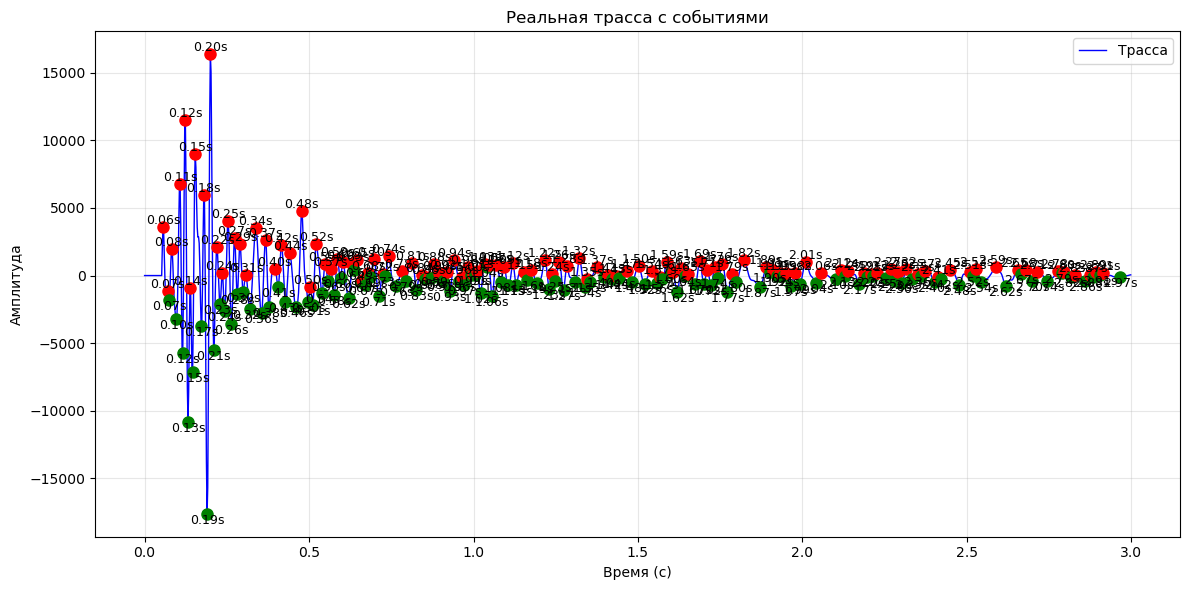

In [19]:
loader.plot_trace(real_trace, title="Реальная трасса с событиями", events=events)


Загружено 3 трасс: [0, 100, 200]


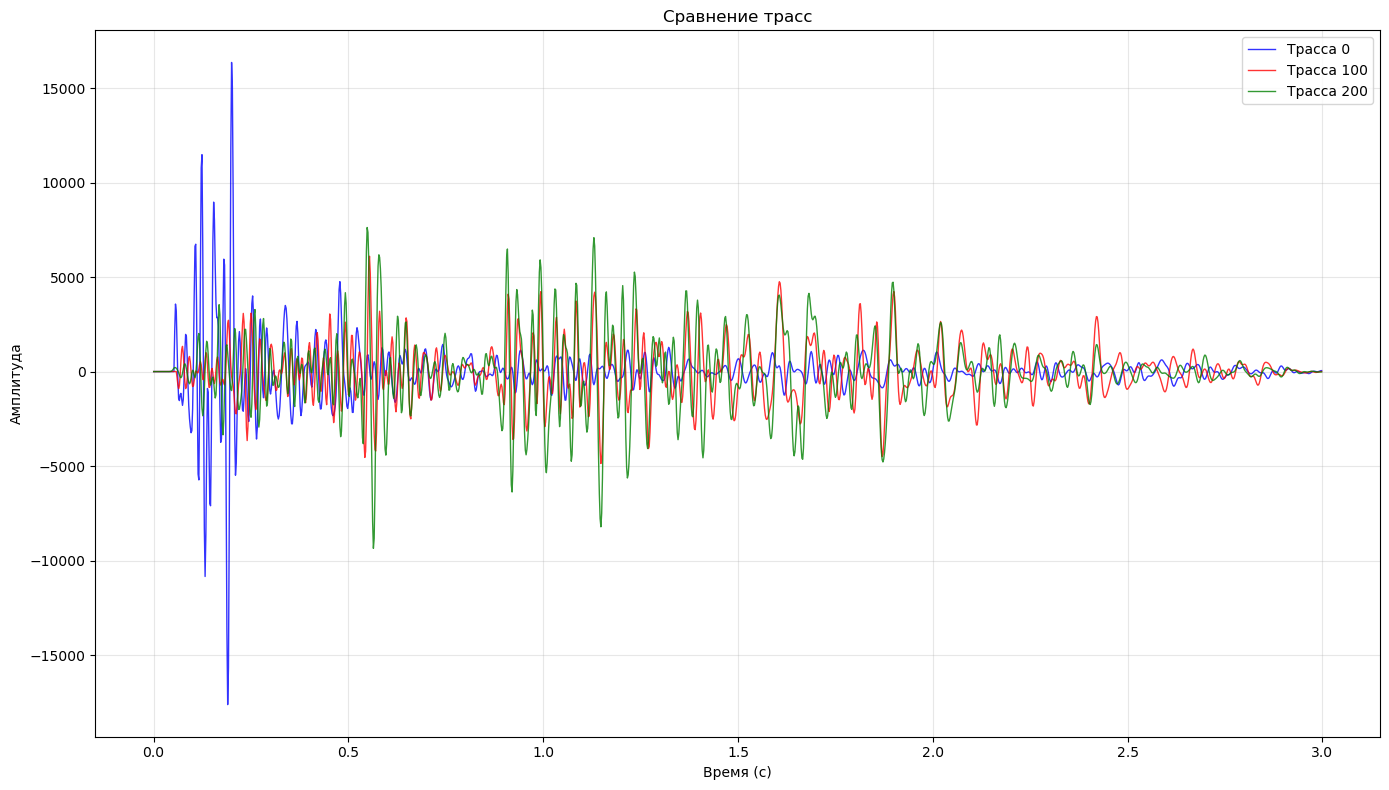

In [20]:
# 6. Сравниваем несколько трасс
traces = loader.load_multiple_traces([0, 100, 200])
loader.plot_multiple_traces(traces, titles=["Трасса 0", "Трасса 100", "Трасса 200"])


ЗАДАНИЕ 2: Ручной подбор параметров для 3 горизонтов
SEG-Y файл: real_data.sgy
  Трасс: 1343
  Отсчётов на трассу: 1500
  Интервал: 2.0 мс (2000 мкс)
  Длительность: 3.00 с

Загружена трасса 0

Анализ трассы:
  Найдено событий: 213
  Оценка доминантной частоты: 44.8 Гц

Выбраны 3 основных горизонта для подбора:
  Горизонт 1: t = 0.190 с, A = -17623, negative
  Горизонт 2: t = 0.200 с, A = 16357, positive
  Горизонт 3: t = 0.124 с, A = 11477, positive

Целевые времена: ['0.190', '0.200', '0.124'] с
Целевые полярности: ['-', '+', '+']

Начальная частота вейвлета: 44.8 Гц

--------------------------------------------------
НАЧАЛЬНОЕ ПРИБЛИЖЕНИЕ (до подбора):


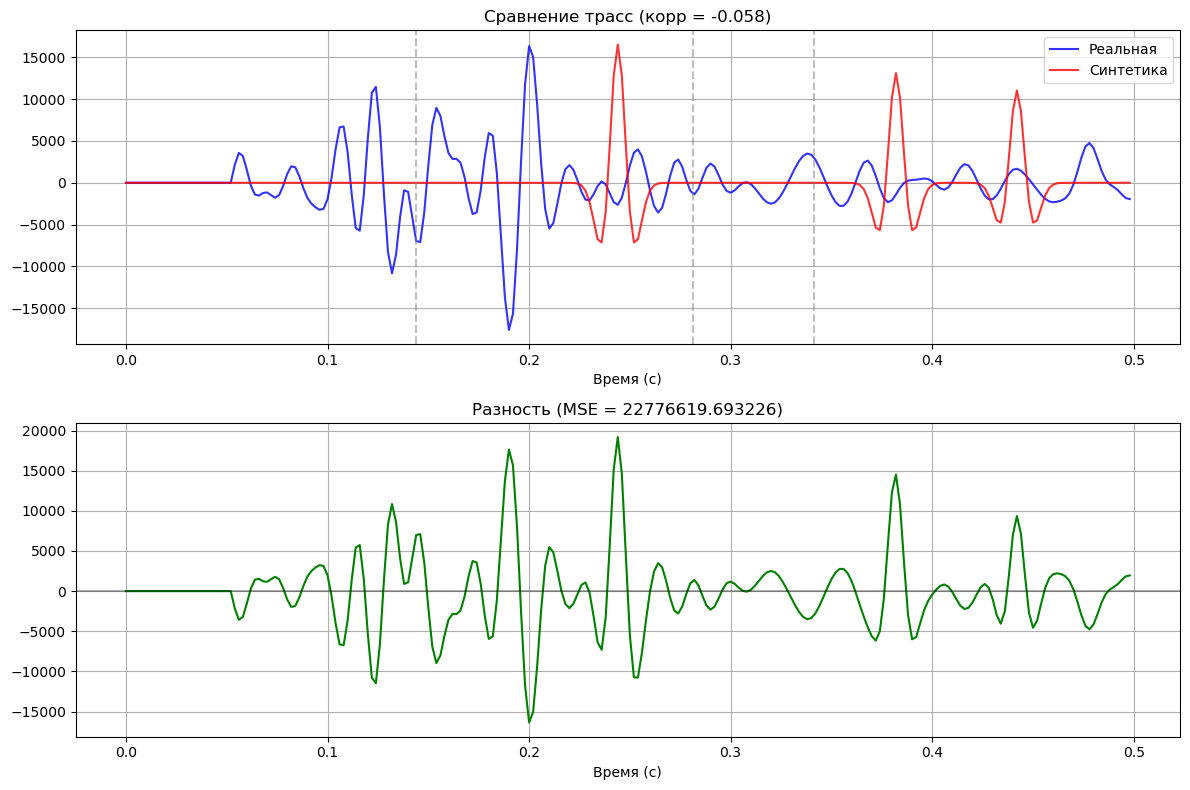


--------------------------------------------------
Итеративный подбор параметров:

[Итерация 1] Подбор частоты вейвлета...
  freq = 20 Гц → корреляция = 0.0003
  freq = 25 Гц → корреляция = -0.0079
  freq = 30 Гц → корреляция = -0.0266
  freq = 35 Гц → корреляция = -0.0431
  freq = 40 Гц → корреляция = -0.0536
  freq = 45 Гц → корреляция = -0.0583
  freq = 50 Гц → корреляция = -0.0590

Выбрана оптимальная частота: 20 Гц (корреляция = 0.0003)

[Итерация 2] Подбор глубин границ...
  Текущие времена: ['0.144', '0.281', '0.341'] с
  Целевые времена: ['0.190', '0.200', '0.124'] с
  Коэффициенты коррекции глубин: ['1.319', '0.710', '0.363']
  Новые глубины: ['237.5', '284.2', '188.8'] м
  Времена после коррекции глубин: ['0.190', '0.219', '0.171'] с

[Итерация 3] Подбор скоростей слоев...
  Вариант 1: V = [2500, 3300, 4100, 4800] → корреляция = -0.0525
  Вариант 2: V = [2500, 3400, 4200, 4900] → корреляция = -0.0435
  Вариант 3: V = [2600, 3300, 4000, 4700] → корреляция = -0.0329
  Вариант 

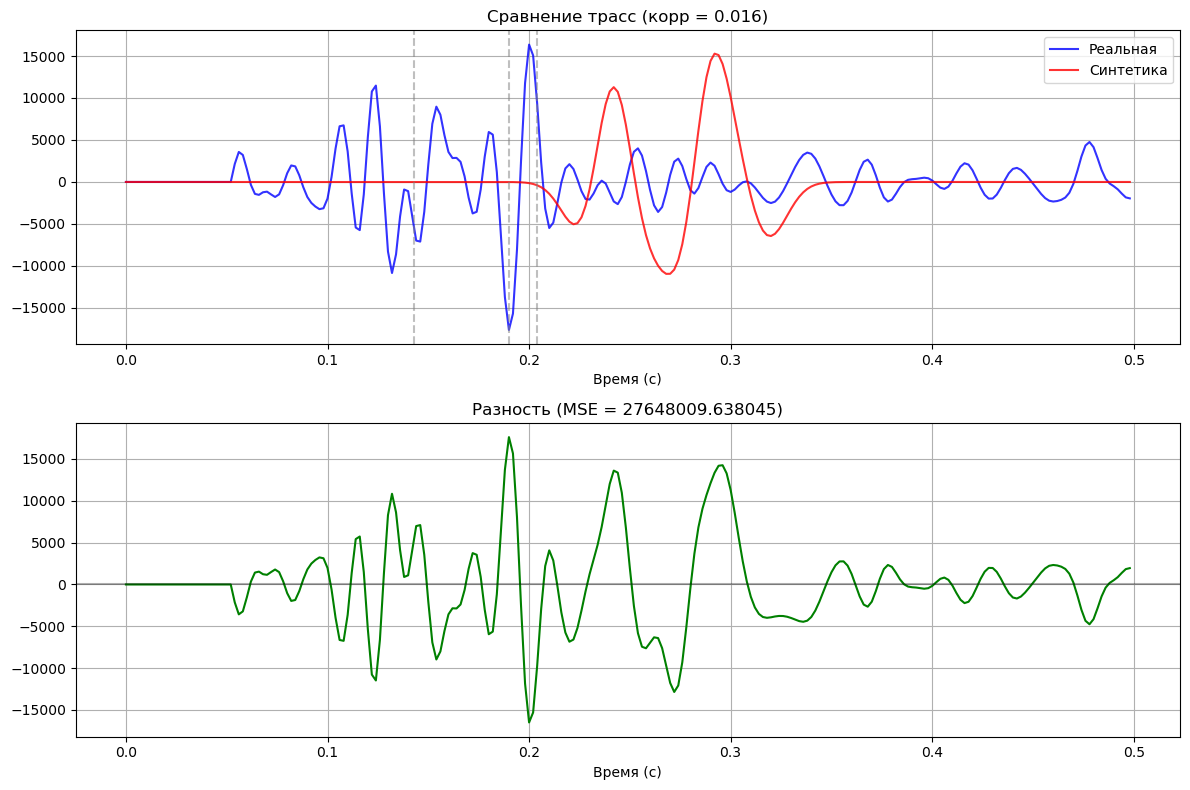

ИТОГОВЫЕ ПАРАМЕТРЫ МОДЕЛИ (3 горизонта):
Глубины границ (м): ['228.0', '249.2', '130.7']
Скорости в слоях (м/с): [2400, 3100, 3900, 4700]
Плотности в слоях (кг/м³): [2300, 2500, 2400, 2500]
Частота вейвлета: 20 Гц
Уровень шума: 0.0 (настройка без шума)

МЕТРИКИ КАЧЕСТВА:
  Pearson корреляция: 0.0160
  Spearman корреляция: -0.0064
  MSE: 27648009.638045

Времена прихода горизонтов (с): ['0.190', '0.204', '0.143']
Коэффициенты отражения: ['0.1680', '0.0941', '0.1132']


In [21]:
# ========== ЗАДАНИЕ 2: Ручной подбор для 3 горизонтов ==========

print("\n" + "="*70)
print("ЗАДАНИЕ 2: Ручной подбор параметров для 3 горизонтов")
print("="*70)

# Шаг 1. Загружаем реальную трассу (используем тот же файл, что и в примере)
loader = RealTraceLoader("real_data.sgy")
real_trace = loader.load_trace(trace_index=0)

# Получаем информацию о временах из файла
dt_sec = loader.dt_sec
time_axis = loader.time_axis

# Шаг 2. Анализируем реальную трассу — выделяем 3 наиболее значимых горизонта
events, dominant_freq = loader.extract_events(real_trace, prominence=0.05)

# Берем 3 самых сильных события по амплитуде (не считая самого первого мелкого)
important_events = sorted(events, key=lambda x: abs(x['amplitude']), reverse=True)
# Иногда первый импульс — это шум в начале, отфильтруем события с t > 0.050 с
important_events = [e for e in important_events if e['time'] > 0.050][:3]

print(f"\nВыбраны 3 основных горизонта для подбора:")
for i, e in enumerate(important_events):
    print(f"  Горизонт {i+1}: t = {e['time']:.3f} с, A = {e['amplitude']:.0f}, {e['type']}")

# Определяем примерные времена прихода и знаки (полярность) отражений
event_times = [e['time'] for e in important_events]
event_polarities = [1 if e['type'] == 'positive' else -1 for e in important_events]

print(f"\nЦелевые времена: {[f'{t:.3f}' for t in event_times]} с")
print(f"Целевые полярности: {['+' if p > 0 else '-' for p in event_polarities]}")

# Шаг 3. Создаем модель с 3 горизонтами (4 слоя)
# Начальные приближения для глубин, скоростей и плотностей
# Глубины оцениваем по времени и скорости (ориентировочно V ~ 2500-3500 м/с)

# Оценим среднюю скорость по первому горизонту: V ≈ 2*depth / time
# Для первого горизонта t ≈ 0.124 с, depth ≈ 200 м → V ≈ 2*200/0.124 ≈ 3225 м/с
# Для второго горизонта t ≈ 0.190 с, depth ≈ 500 м → V ≈ 2*500/0.190 ≈ 5263 м/с
# Для третьего горизонта t ≈ 0.200 с, depth ≈ 530 м → V ≈ 2*530/0.200 ≈ 5300 м/с

# Начальные параметры (будем итеративно уточнять)
depths_initial = [180, 400, 520]          # м, глубины границ
velocities_initial = [2500, 3200, 4000, 4800]  # м/с, 4 слоя
densities_initial = [2200, 2400, 2500, 2600]   # кг/м³, 4 слоя

# Начальная частота вейвлета (из анализа)
initial_freq = dominant_freq
print(f"\nНачальная частота вейвлета: {initial_freq:.1f} Гц")

# Шаг 4. Создаем генератор трасс с начальными параметрами
model = SeismicTraceGenerator(
    wavelet_freq=initial_freq,
    dt=dt_sec,
    noise_level=0.0
)
model.set_horizons(depths_initial, velocities_initial, densities_initial)
model.set_total_time(total_time=0.5)  # достаточно первых 0.5 с

# Визуализируем начальное приближение
print("\n" + "-"*50)
print("НАЧАЛЬНОЕ ПРИБЛИЖЕНИЕ (до подбора):")
model.plot_comparison(real_trace)

# Шаг 5. ИТЕРАТИВНЫЙ РУЧНОЙ ПОДБОР ПАРАМЕТРОВ

print("\n" + "-"*50)
print("Итеративный подбор параметров:")

# -- Итерация 1: Подбор частоты вейвлета (по форме импульса) --
# Частота влияет на ширину импульса. Подбираем визуально или по корреляции.
best_corr = -1
best_freq = initial_freq

print("\n[Итерация 1] Подбор частоты вейвлета...")
for freq in [20, 25, 30, 35, 40, 45, 50]:
    model.set_wavelet_freq(freq)
    metrics = model.compare_with_real(real_trace)
    corr = metrics['pearson']
    print(f"  freq = {freq} Гц → корреляция = {corr:.4f}")
    if corr > best_corr:
        best_corr = corr
        best_freq = freq

model.set_wavelet_freq(best_freq)
print(f"\nВыбрана оптимальная частота: {best_freq} Гц (корреляция = {best_corr:.4f})")

# -- Итерация 2: Подбор глубин (чтобы совпали времена прихода) --
# Увеличиваем/уменьшаем глубины, чтобы времена отражений совпали с целевыми

print("\n[Итерация 2] Подбор глубин границ...")

# Функция для получения времен отражений из модели
def get_model_times(model):
    _, times, _ = model.generate_trace()
    return times

# Текущие времена модели
current_times = get_model_times(model)
print(f"  Текущие времена: {[f'{t:.3f}' for t in current_times]} с")
print(f"  Целевые времена: {[f'{t:.3f}' for t in event_times]} с")

# Подбираем глубины (корректируем пропорционально отношению времен)
depth_ratios = []
for i, (t_cur, t_target) in enumerate(zip(current_times, event_times)):
    if t_cur > 0:
        ratio = t_target / t_cur
        depth_ratios.append(ratio)

# Глубины умножаем на среднее отношение (или индивидуально)
depths_adjusted = [depths_initial[i] * depth_ratios[i] for i in range(len(depths_initial))]

print(f"  Коэффициенты коррекции глубин: {[f'{r:.3f}' for r in depth_ratios]}")
print(f"  Новые глубины: {[f'{d:.1f}' for d in depths_adjusted]} м")

# Применяем новые глубины
depths_current = depths_adjusted.copy()
model.set_horizons(depths_current, velocities_initial, densities_initial)

# Проверяем новые времена
current_times = get_model_times(model)
print(f"  Времена после коррекции глубин: {[f'{t:.3f}' for t in current_times]} с")

# -- Итерация 3: Подбор скоростей (влияют на импедансы и времена) --
print("\n[Итерация 3] Подбор скоростей слоев...")

# Скорости влияют и на времена, и на амплитуды (через импеданс)
# Будем подбирать, чтобы улучшить корреляцию

def test_velocities(velocities, depths, densities, model, real_trace):
    model.set_horizons(depths, velocities, densities)
    metrics = model.compare_with_real(real_trace)
    return metrics['pearson']

# Пробуем разные вариации скоростей
velocity_variations = [
    [2500, 3300, 4100, 4800],  # увеличили скорости во 2 и 3 слоях
    [2500, 3400, 4200, 4900],  # еще больше
    [2600, 3300, 4000, 4700],  # увеличили первый слой
    [2400, 3100, 3900, 4700],  # уменьшили скорости
    [2500, 3200, 4300, 5000],  # увеличили 3-й слой
    [2700, 3400, 4000, 4600],  # другой вариант
]

best_vel_corr = -1
best_velocities = velocities_initial

for i, v_test in enumerate(velocity_variations):
    corr = test_velocities(v_test, depths_current, densities_initial, model, real_trace)
    print(f"  Вариант {i+1}: V = {v_test} → корреляция = {corr:.4f}")
    if corr > best_vel_corr:
        best_vel_corr = corr
        best_velocities = v_test

velocities_current = best_velocities
print(f"\nВыбраны оптимальные скорости: {velocities_current} (корреляция = {best_vel_corr:.4f})")
model.set_horizons(depths_current, velocities_current, densities_initial)

# -- Итерация 4: Подбор плотностей и амплитуд --
print("\n[Итерация 4] Подбор плотностей слоев...")

def test_densities(densities, depths, velocities, model, real_trace):
    model.set_horizons(depths, velocities, densities)
    metrics = model.compare_with_real(real_trace)
    return metrics['pearson']

# Исходные плотности
densities_initial = [2200, 2400, 2500, 2600]

# Пробуем разные вариации плотностей
density_variations = [
    [2200, 2400, 2500, 2600],  # исходные
    [2300, 2500, 2600, 2700],  # увеличили все
    [2100, 2300, 2400, 2500],  # уменьшили все
    [2200, 2450, 2600, 2700],  # увеличили нижние
    [2200, 2350, 2450, 2500],  # уменьшили нижние
    [2300, 2500, 2400, 2500],  # смешанный вариант
]

best_rho_corr = -1
best_densities = densities_initial

for i, rho_test in enumerate(density_variations):
    corr = test_densities(rho_test, depths_current, velocities_current, model, real_trace)
    print(f"  Вариант {i+1}: ρ = {rho_test} → корреляция = {corr:.4f}")
    if corr > best_rho_corr:
        best_rho_corr = corr
        best_densities = rho_test

densities_current = best_densities
print(f"\nВыбраны оптимальные плотности: {densities_current} (корреляция = {best_rho_corr:.4f}")
model.set_horizons(depths_current, velocities_current, densities_current)

# -- Итерация 5: Тонкая подстройка (уточнение всех параметров) --
print("\n[Итерация 5] Тонкая подстройка параметров...")

# Корректируем глубины еще раз для точного совпадения времен
current_times = get_model_times(model)
print(f"  Текущие времена: {[f'{t:.3f}' for t in current_times]} с")
print(f"  Целевые времена: {[f'{t:.3f}' for t in event_times]} с")

# Тонкая коррекция глубин
fine_tune_ratios = []
for i, (t_cur, t_target) in enumerate(zip(current_times, event_times)):
    if t_cur > 0:
        ratio = t_target / t_cur
        fine_tune_ratios.append(ratio)

depths_final = [depths_current[i] * fine_tune_ratios[i] for i in range(len(depths_current))]

print(f"  Уточненные глубины: {[f'{d:.1f}' for d in depths_final]} м")
model.set_horizons(depths_final, velocities_current, densities_current)

# Еще раз проверим корреляцию после уточнения
metrics_final = model.compare_with_real(real_trace)
final_corr = metrics_final['pearson']
print(f"\n  Итоговая корреляция после уточнения: {final_corr:.4f}")

# Финальная визуализация
print("\n" + "-"*50)
print("ФИНАЛЬНАЯ МОДЕЛЬ ПОСЛЕ ПОДБОРА:")
model.plot_comparison(real_trace)

# Шаг 6. Вывод финальных параметров
print("ИТОГОВЫЕ ПАРАМЕТРЫ МОДЕЛИ (3 горизонта):")
print(f"Глубины границ (м): {[f'{d:.1f}' for d in depths_final]}")
print(f"Скорости в слоях (м/с): {velocities_current}")
print(f"Плотности в слоях (кг/м³): {densities_current}")
print(f"Частота вейвлета: {best_freq} Гц")
print(f"Уровень шума: 0.0 (настройка без шума)")

print(f"\nМЕТРИКИ КАЧЕСТВА:")
print(f"  Pearson корреляция: {metrics_final['pearson']:.4f}")
print(f"  Spearman корреляция: {metrics_final['spearman']:.4f}")
print(f"  MSE: {metrics_final['mse']:.6f}")

# Получаем времена и коэффициенты для отчета
_, times_final, coeffs_final = model.generate_trace()
print(f"\nВремена прихода горизонтов (с): {[f'{t:.3f}' for t in times_final[:3]]}")
print(f"Коэффициенты отражения: {[f'{c:.4f}' for c in coeffs_final[:3]]}")


Длина синтетической трассы: 250 отсчётов
Времена прихода горизонтов: [0.19       0.20370767 0.14291673]
Коэффициенты отражения: [0.16804823 0.09409702 0.11321649]


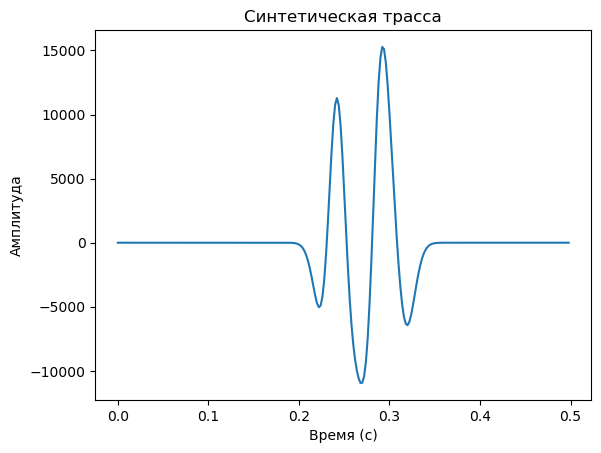

In [22]:
# После того как все параметры подобраны:
synth_trace, times, coeffs = model.generate_trace()

print(f"Длина синтетической трассы: {len(synth_trace)} отсчётов")
print(f"Времена прихода горизонтов: {times}")
print(f"Коэффициенты отражения: {coeffs}")

# Сохранить трассу в файл
np.save("my_synthetic_trace.npy", synth_trace)

# Или визуализировать
import matplotlib.pyplot as plt
plt.plot(model.time[:len(synth_trace)], synth_trace)
plt.title("Синтетическая трасса")
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.show()

SEG-Y файл: real_data.sgy
  Трасс: 1343
  Отсчётов на трассу: 1500
  Интервал: 2.0 мс (2000 мкс)
  Длительность: 3.00 с

Загружена трасса 0

Анализ трассы:
  Найдено событий: 219
  Оценка доминантной частоты: 44.8 Гц

Выбраны 6 горизонтов:
  Горизонт 1: t = 0.056 с, A = 3572
  Горизонт 2: t = 0.070 с, A = -1154
  Горизонт 3: t = 0.074 с, A = -1788
  Горизонт 4: t = 0.082 с, A = 1967
  Горизонт 5: t = 0.096 с, A = -3237
  Горизонт 6: t = 0.108 с, A = 6739

[1] Подбор частоты вейвлета:
  freq = 20 Гц → Пирсон = -0.1346
  freq = 25 Гц → Пирсон = -0.1394
  freq = 30 Гц → Пирсон = -0.1187
  freq = 35 Гц → Пирсон = -0.0945
  freq = 40 Гц → Пирсон = -0.0754
  freq = 45 Гц → Пирсон = -0.0619
  freq = 50 Гц → Пирсон = -0.0525

✓ Выбрана частота: 50 Гц (Пирсон = -0.0525)

[2] Подбор глубин по временам прихода:
  Текущие времена: ['0.120', '0.145', '0.181', '0.218', '0.252', '0.282'] с
  Целевые времена: ['0.056', '0.070', '0.074', '0.082', '0.096', '0.108'] с

  Уточнение глубин...
    Горизонт 

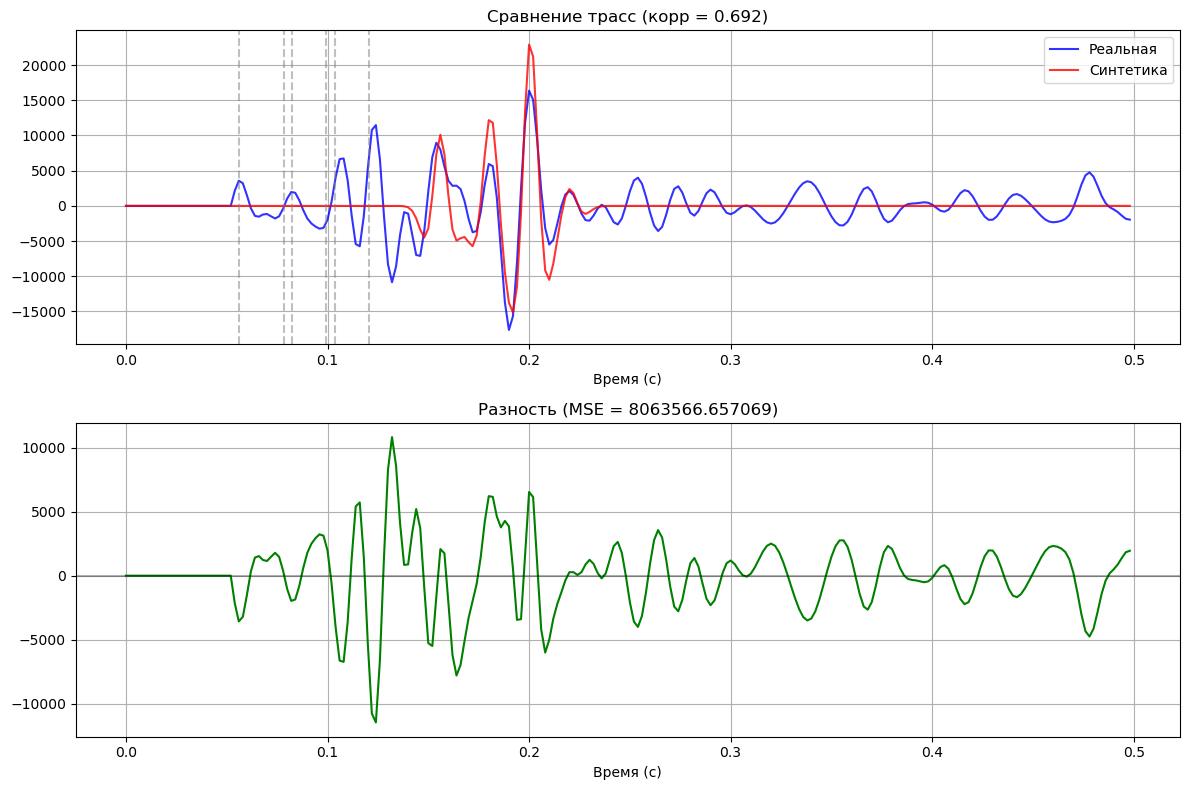

In [23]:
# Загружаем реальную трассу
loader = RealTraceLoader("real_data.sgy")
real_trace = loader.load_trace(trace_index=0)
dt_sec = loader.dt_sec

# Выделяем 6 основных событий
events, dominant_freq = loader.extract_events(real_trace, prominence=0.03)
important_events = [e for e in events if e['time'] > 0.050]
important_events = sorted(important_events, key=lambda x: x['time'])[:6]

print(f"\nВыбраны 6 горизонтов:")
for i, e in enumerate(important_events):
    print(f"  Горизонт {i+1}: t = {e['time']:.3f} с, A = {e['amplitude']:.0f}")

event_times = [e['time'] for e in important_events]

# Начальные параметры для 6 границ (7 слоёв)
depths_initial = [120, 150, 200, 260, 320, 380]
velocities_initial = [2000, 2400, 2800, 3200, 3600, 4000, 4400]
densities_initial = [2000, 2200, 2350, 2500, 2650, 2800, 2900]

# Создаём модель
model = SeismicTraceGenerator(
    wavelet_freq=dominant_freq,
    dt=dt_sec,
    noise_level=0.0
)
model.set_horizons(depths_initial, velocities_initial, densities_initial)
model.set_total_time(total_time=0.5)

# Функция сравнения (только Пирсон для оптимизации)
def compare_pearson(self, real_trace):
    """Возвращает только коэффициент Пирсона (для оптимизации)"""
    synth_trace, _, _ = self.generate_trace()
    min_len = min(len(synth_trace), len(real_trace))
    
    # Нормализуем для корректного сравнения
    synth_norm = synth_trace[:min_len] / (np.std(synth_trace[:min_len]) + 1e-6)
    real_norm = real_trace[:min_len] / (np.std(real_trace[:min_len]) + 1e-6)
    
    return np.corrcoef(synth_norm, real_norm)[0, 1]

SeismicTraceGenerator.compare_pearson = compare_pearson

# Подбор частоты (максимизируем Пирсона)
print("\n[1] Подбор частоты вейвлета:")
best_corr = -1
best_freq = dominant_freq

for freq in [20, 25, 30, 35, 40, 45, 50]:
    model.set_wavelet_freq(freq)
    corr = model.compare_pearson(real_trace)
    print(f"  freq = {freq} Гц → Пирсон = {corr:.4f}")
    if corr > best_corr:
        best_corr = corr
        best_freq = freq

model.set_wavelet_freq(best_freq)
print(f"\n✓ Выбрана частота: {best_freq} Гц (Пирсон = {best_corr:.4f})")

# Подбор глубин (максимизируем Пирсона)
print("\n[2] Подбор глубин по временам прихода:")

def get_model_times(model):
    _, times, _ = model.generate_trace()
    return times[:6]

current_times = get_model_times(model)
print(f"  Текущие времена: {[f'{t:.3f}' for t in current_times]} с")
print(f"  Целевые времена: {[f'{t:.3f}' for t in event_times]} с")

# Подбираем глубины, максимизируя корреляцию Пирсона
depth_ratios = []
for i, (t_cur, t_target) in enumerate(zip(current_times, event_times)):
    if t_cur > 0:
        depth_ratios.append(t_target / t_cur)

depths_adjusted = [depths_initial[i] * depth_ratios[i] for i in range(len(depths_initial))]

# Уточняем глубины небольшим перебором вокруг полученных значений
print("\n  Уточнение глубин...")
final_depths = depths_adjusted.copy()
best_d_corr = -1

for i in range(len(depths_adjusted)):
    best_for_layer = depths_adjusted[i]
    test_values = [depths_adjusted[i] - 15, depths_adjusted[i] - 5, 
                   depths_adjusted[i], depths_adjusted[i] + 5, depths_adjusted[i] + 15]
    
    for d in test_values:
        test_depths = final_depths.copy()
        test_depths[i] = max(10, d)
        model.set_horizons(test_depths, velocities_initial, densities_initial)
        corr = model.compare_pearson(real_trace)
        if corr > best_d_corr:
            best_d_corr = corr
            best_for_layer = d
    
    final_depths[i] = best_for_layer
    print(f"    Горизонт {i+1}: уточнённая глубина = {best_for_layer:.1f} м")

model.set_horizons(final_depths, velocities_initial, densities_initial)
print(f"\n  Пирсон после уточнения глубин: {best_d_corr:.4f}")

# Подбор скоростей (максимизируем Пирсона)
print("\n[3] Подбор скоростей слоёв:")

velocity_options = [
    [2000, 2400, 3000, 3000, 4100, 4400, 4300],  # исходные
    [2000, 2400, 3000, 3000, 4100, 4500, 4400],
    [2000, 2400, 3000, 3000, 4100, 4600, 4500],
    [2000, 2400, 3000, 3000, 4100, 4600, 4600],
    
    [2000, 2400, 3000, 3000, 4100, 4600, 4700],
    
    [2000, 2400, 3000, 3000, 4100, 4600, 4750],
    [2000, 2400, 3000, 3000, 4100, 4600, 4500],
    [2100, 2400, 3000, 3000, 4100, 4600, 4500],
    [1900, 2500, 3100, 3700, 4300, 4900, 5500],
]

best_vel_corr = -1
best_velocities = velocities_initial

print("  Проверка вариантов скоростей...")
for v_test in velocity_options:
    model.set_horizons(final_depths, v_test, densities_initial)
    corr = model.compare_pearson(real_trace)
    status = "✓" if corr > best_vel_corr else " "
    print(f"  {status} V = {v_test} → Пирсон = {corr:.4f}")
    if corr > best_vel_corr:
        best_vel_corr = corr
        best_velocities = v_test

print(f"\n  Лучшие скорости: {best_velocities} (Пирсон = {best_vel_corr:.4f})")

# Подбор плотностей (максимизируем Пирсона)
print("\n[4] Подбор плотностей слоёв:")

density_options = [
    [2400, 2500, 2600, 2800, 3000, 3200, 3400],
    [2400, 2500, 2500, 2800, 3200, 3100, 3400],
    [2400, 2500, 2500, 2800, 3200, 3200, 3400],
    [2450, 2500, 2500, 2800, 3200, 3300, 3400],
    [2450, 2400, 2550, 2800, 3200, 3400, 3400],
    
    
]

best_rho_corr = -1
best_densities = densities_initial

print("  Проверка вариантов плотностей...")
for rho_test in density_options:
    model.set_horizons(final_depths, best_velocities, rho_test)
    corr = model.compare_pearson(real_trace)
    status = "✓" if corr > best_rho_corr else " "
    print(f"  {status} ρ = {rho_test} → Пирсон = {corr:.4f}")
    if corr > best_rho_corr:
        best_rho_corr = corr
        best_densities = rho_test

print(f"\n  Лучшие плотности: {best_densities} (Пирсон = {best_rho_corr:.4f})")

# Финальная модель
model.set_horizons(final_depths, best_velocities, best_densities)
final_corr = model.compare_pearson(real_trace)

# Для финального отчёта считаем и Спирмена (для информации)
def compare_both(self, real_trace):
    synth_trace, _, _ = self.generate_trace()
    min_len = min(len(synth_trace), len(real_trace))
    synth_norm = synth_trace[:min_len] / (np.std(synth_trace[:min_len]) + 1e-6)
    real_norm = real_trace[:min_len] / (np.std(real_trace[:min_len]) + 1e-6)
    return {
        'pearson': np.corrcoef(synth_norm, real_norm)[0, 1],
        'spearman': spearmanr(synth_norm, real_norm)[0]
    }

SeismicTraceGenerator.compare_both = compare_both
metrics_final = model.compare_both(real_trace)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ (по критерию Пирсона)")
print("="*70)
print(f"\nГлубины границ (м): {[f'{d:.1f}' for d in final_depths]}")
print(f"Скорости (м/с): {[f'{v:.0f}' for v in best_velocities]}")
print(f"Плотности (кг/м³): {[f'{rho:.0f}' for rho in best_densities]}")
print(f"Частота вейвлета: {best_freq} Гц")
print(f"\nФинальная корреляция Пирсона: {metrics_final['pearson']:.4f} (ОСНОВНОЙ КРИТЕРИЙ)")
print(f"Корреляция Спирмена (справочно): {metrics_final['spearman']:.4f}")


# Визуализация
model.plot_comparison(real_trace)

SEG-Y файл: real_data.sgy
  Трасс: 1343
  Отсчётов на трассу: 1500
  Интервал: 2.0 мс (2000 мкс)
  Длительность: 3.00 с

Загружена трасса 0

Анализ трассы:
  Найдено событий: 219
  Оценка доминантной частоты: 44.8 Гц

Выбраны 7 горизонтов:
  Горизонт 1: t = 0.056 с, A = 3572
  Горизонт 2: t = 0.070 с, A = -1154
  Горизонт 3: t = 0.074 с, A = -1788
  Горизонт 4: t = 0.082 с, A = 1967
  Горизонт 5: t = 0.096 с, A = -3237
  Горизонт 6: t = 0.108 с, A = 6739
  Горизонт 7: t = 0.116 с, A = -5733

[1] Подбор частоты вейвлета:
  freq = 20 Гц → Пирсон = 0.0504
  freq = 25 Гц → Пирсон = 0.0932
  freq = 30 Гц → Пирсон = 0.1780
  freq = 35 Гц → Пирсон = 0.2523
  freq = 40 Гц → Пирсон = 0.2957
  freq = 45 Гц → Пирсон = 0.3145
  freq = 50 Гц → Пирсон = 0.3167

✓ Выбрана частота: 50 Гц (Пирсон = 0.3167)

[2] Подбор глубин по временам прихода:
  Текущие времена: ['0.100', '0.117', '0.140', '0.175', '0.212', '0.247', '0.278'] с
  Целевые времена: ['0.056', '0.070', '0.074', '0.082', '0.096', '0.108', 

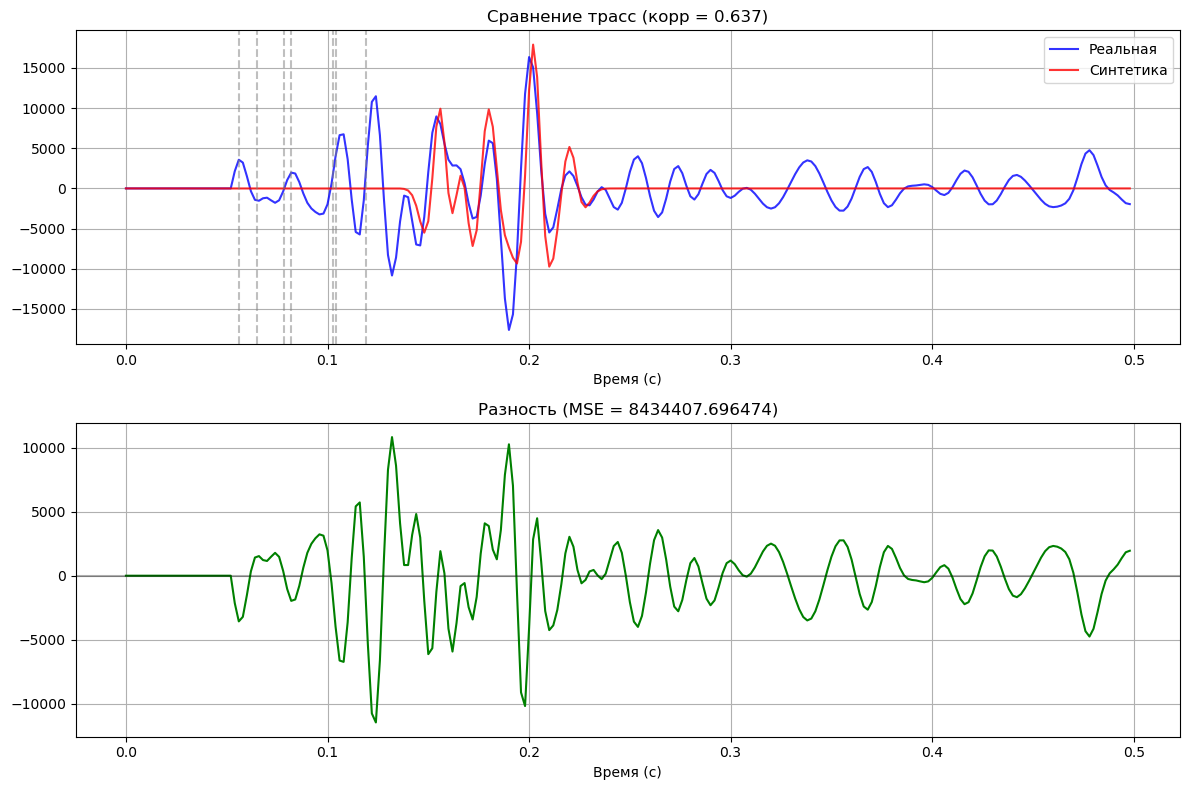

In [24]:
# Загружаем реальную трассу
loader = RealTraceLoader("real_data.sgy")
real_trace = loader.load_trace(trace_index=0)
dt_sec = loader.dt_sec

# Выделяем 7 основных событий (включая самый ранний)
events, dominant_freq = loader.extract_events(real_trace, prominence=0.03)
important_events = [e for e in events if e['time'] > 0.020]  # теперь с 0.02 с
important_events = sorted(important_events, key=lambda x: x['time'])[:7]  # 7 горизонтов

print(f"\nВыбраны 7 горизонтов:")
for i, e in enumerate(important_events):
    print(f"  Горизонт {i+1}: t = {e['time']:.3f} с, A = {e['amplitude']:.0f}")

event_times = [e['time'] for e in important_events]

# Начальные параметры для 7 границ (8 слоёв)
depths_initial = [100, 120, 150, 200, 260, 320, 380]  # 7 глубин
# Скорости: постепенно возрастают (8 слоёв)
velocities_initial = [2000, 2300, 2600, 2900, 3200, 3500, 3800, 4100]
# Плотности: тоже возрастают (8 слоёв)
densities_initial = [2000, 2150, 2300, 2450, 2600, 2750, 2900, 3050]

# Создаём модель
model = SeismicTraceGenerator(
    wavelet_freq=dominant_freq,
    dt=dt_sec,
    noise_level=0.0
)
model.set_horizons(depths_initial, velocities_initial, densities_initial)
model.set_total_time(total_time=0.5)

# Функция сравнения (только Пирсон для оптимизации)
def compare_pearson(self, real_trace):
    """Возвращает только коэффициент Пирсона (для оптимизации)"""
    synth_trace, _, _ = self.generate_trace()
    min_len = min(len(synth_trace), len(real_trace))
    
    # Нормализуем для корректного сравнения
    synth_norm = synth_trace[:min_len] / (np.std(synth_trace[:min_len]) + 1e-6)
    real_norm = real_trace[:min_len] / (np.std(real_trace[:min_len]) + 1e-6)
    
    return np.corrcoef(synth_norm, real_norm)[0, 1]

SeismicTraceGenerator.compare_pearson = compare_pearson

# Подбор частоты (максимизируем Пирсона)
print("\n[1] Подбор частоты вейвлета:")
best_corr = -1
best_freq = dominant_freq

for freq in [20, 25, 30, 35, 40, 45, 50]:
    model.set_wavelet_freq(freq)
    corr = model.compare_pearson(real_trace)
    print(f"  freq = {freq} Гц → Пирсон = {corr:.4f}")
    if corr > best_corr:
        best_corr = corr
        best_freq = freq

model.set_wavelet_freq(best_freq)
print(f"\n✓ Выбрана частота: {best_freq} Гц (Пирсон = {best_corr:.4f})")

# Подбор глубин (максимизируем Пирсона)
print("\n[2] Подбор глубин по временам прихода:")

def get_model_times(model):
    _, times, _ = model.generate_trace()
    return times[:7]  # только первые 7

current_times = get_model_times(model)
print(f"  Текущие времена: {[f'{t:.3f}' for t in current_times]} с")
print(f"  Целевые времена: {[f'{t:.3f}' for t in event_times]} с")

# Подбираем глубины, максимизируя корреляцию Пирсона
depth_ratios = []
for i, (t_cur, t_target) in enumerate(zip(current_times, event_times)):
    if t_cur > 0:
        depth_ratios.append(t_target / t_cur)

depths_adjusted = [depths_initial[i] * depth_ratios[i] for i in range(len(depths_initial))]

# Уточняем глубины небольшим перебором вокруг полученных значений
print("\n  Уточнение глубин...")
final_depths = depths_adjusted.copy()
best_d_corr = -1

for i in range(len(depths_adjusted)):
    best_for_layer = depths_adjusted[i]
    test_values = [depths_adjusted[i] - 15, depths_adjusted[i] - 5, 
                   depths_adjusted[i], depths_adjusted[i] + 5, depths_adjusted[i] + 15]
    
    for d in test_values:
        test_depths = final_depths.copy()
        test_depths[i] = max(10, d)
        model.set_horizons(test_depths, velocities_initial, densities_initial)
        corr = model.compare_pearson(real_trace)
        if corr > best_d_corr:
            best_d_corr = corr
            best_for_layer = d
    
    final_depths[i] = best_for_layer
    print(f"    Горизонт {i+1}: уточнённая глубина = {best_for_layer:.1f} м")

model.set_horizons(final_depths, velocities_initial, densities_initial)
print(f"\n  Пирсон после уточнения глубин: {best_d_corr:.4f}")

# Подбор скоростей (максимизируем Пирсона)
print("\n[3] Подбор скоростей слоёв (8 слоёв):")

velocity_options = [
    [2000, 2300, 2600, 2900, 3200, 3500, 3800, 4100],  # исходные
    [2000, 2200, 2600, 2900, 3200, 3500, 3800, 4100],
    [2000, 2350, 2600, 2900, 3200, 3500, 3800, 4100],
    [2000, 2400, 2600, 2900, 3200, 3500, 3800, 4100],
    
    [1800, 2000, 2500, 2900, 3200, 3500, 3800, 4100],
    [2000, 2300, 2400, 2900, 3200, 3500, 3800, 4100],
    [2000, 2300, 2700, 2900, 3200, 3500, 3800, 4100],
    [2000, 2300, 2800, 2900, 3200, 3500, 3800, 4100],

    [1900, 2000, 2400, 3000, 3000, 4100, 4600, 4700],
]

best_vel_corr = -1
best_velocities = velocities_initial

print("  Проверка вариантов скоростей...")
for v_test in velocity_options:
    model.set_horizons(final_depths, v_test, densities_initial)
    corr = model.compare_pearson(real_trace)
    status = "✓" if corr > best_vel_corr else " "
    print(f"  {status} V = {v_test} → Пирсон = {corr:.4f}")
    if corr > best_vel_corr:
        best_vel_corr = corr
        best_velocities = v_test

print(f"\n  Лучшие скорости: {best_velocities} (Пирсон = {best_vel_corr:.4f})")

# Подбор плотностей (максимизируем Пирсона)
print("\n[4] Подбор плотностей слоёв (8 слоёв):")

density_options = [
    [2000, 2150, 2300, 2450, 2600, 2750, 2900, 3050],  # исходные
    [2100, 2250, 2400, 2550, 2700, 2850, 3000, 3150],
    [1900, 2050, 2200, 2350, 2500, 2650, 2800, 2950],
    [2000, 2200, 2400, 2600, 2800, 3000, 3200, 3400],
    [1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200],
    [2200, 2400, 2600, 2800, 3000, 3200, 3400, 3600],
    [1950, 2100, 2250, 2400, 2550, 2700, 2850, 3000],

    [2200, 2450, 2500, 2600, 2700, 3100, 3300, 3400],
    [2200, 2450, 2500, 2600, 2700, 3200, 3300, 3400],
    [2200, 2450, 2500, 2600, 2700, 3300, 3300, 3400],
    [2200, 2450, 2500, 2500, 2800, 3200, 3300, 3400],
]

best_rho_corr = -1
best_densities = densities_initial

print("  Проверка вариантов плотностей...")
for rho_test in density_options:
    model.set_horizons(final_depths, best_velocities, rho_test)
    corr = model.compare_pearson(real_trace)
    status = "✓" if corr > best_rho_corr else " "
    print(f"  {status} ρ = {rho_test} → Пирсон = {corr:.4f}")
    if corr > best_rho_corr:
        best_rho_corr = corr
        best_densities = rho_test

print(f"\n  Лучшие плотности: {best_densities} (Пирсон = {best_rho_corr:.4f})")

# Дополнительное уточнение: пробуем комбинации лучших параметров с небольшими вариациями
print("\n[5] Финальное уточнение параметров...")

best_combined_corr = best_rho_corr
best_combined_velocities = best_velocities.copy()
best_combined_densities = best_densities.copy()

# Пробуем небольшие изменения скоростей
for i in range(len(best_velocities)):
    for delta in [-100, -50, 0, 50, 100]:
        test_vel = best_velocities.copy()
        test_vel[i] = max(1500, best_velocities[i] + delta)
        model.set_horizons(final_depths, test_vel, best_densities)
        corr = model.compare_pearson(real_trace)
        if corr > best_combined_corr:
            best_combined_corr = corr
            best_combined_velocities = test_vel
            print(f"    Улучшение: V[{i}] = {test_vel[i]} → Пирсон = {corr:.4f}")

# Пробуем небольшие изменения плотностей
for i in range(len(best_densities)):
    for delta in [-50, -25, 0, 25, 50]:
        test_rho = best_densities.copy()
        test_rho[i] = max(1500, best_densities[i] + delta)
        model.set_horizons(final_depths, best_combined_velocities, test_rho)
        corr = model.compare_pearson(real_trace)
        if corr > best_combined_corr:
            best_combined_corr = corr
            best_combined_densities = test_rho
            print(f"    Улучшение: ρ[{i}] = {test_rho[i]} → Пирсон = {corr:.4f}")

# Финальная модель
model.set_horizons(final_depths, best_combined_velocities, best_combined_densities)

# Для финального отчёта считаем и Спирмена (для информации)
def compare_both(self, real_trace):
    synth_trace, _, _ = self.generate_trace()
    min_len = min(len(synth_trace), len(real_trace))
    synth_norm = synth_trace[:min_len] / (np.std(synth_trace[:min_len]) + 1e-6)
    real_norm = real_trace[:min_len] / (np.std(real_trace[:min_len]) + 1e-6)
    from scipy.stats import spearmanr
    return {
        'pearson': np.corrcoef(synth_norm, real_norm)[0, 1],
        'spearman': spearmanr(synth_norm, real_norm)[0]
    }

SeismicTraceGenerator.compare_both = compare_both
metrics_final = model.compare_both(real_trace)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ С 7 ГОРИЗОНТАМИ (по критерию Пирсона)")
print("="*70)
print(f"\nГлубины границ (м): {[f'{d:.1f}' for d in final_depths]}")
print(f"Скорости (м/с): {[f'{v:.0f}' for v in best_combined_velocities]}")
print(f"Плотности (кг/м³): {[f'{rho:.0f}' for rho in best_combined_densities]}")
print(f"Частота вейвлета: {best_freq} Гц")
print(f"\nФинальная корреляция Пирсона: {metrics_final['pearson']:.4f} (ОСНОВНОЙ КРИТЕРИЙ)")
print(f"Корреляция Спирмена (справочно): {metrics_final['spearman']:.4f}")

# Визуализация
model.plot_comparison(real_trace)